In [2]:
# Creamos el módulo auxiliar 
contenido_modulo = '''

import numpy as np
# Calcula el precio con descuento aplicado.
def calcular_descuento(precio, porcentaje):
    if not (0 <= porcentaje <= 100):
        raise ValueError(f"El porcentaje de descuento debe estar entre 0 y 100, se recibió: {porcentaje}")
    return precio * (1 - porcentaje / 100)

#Convertir un número en moneda
def formatear_moneda(cantidad):
    return f"${cantidad:,.2f}"

#Calcular estadísticas sobre una lista de cantidades vendidas
def estadisticas_ventas(cantidades):
    arr = np.array(cantidades)
    return {
        "total": np.sum(arr),
        "promedio": np.mean(arr),
        "mediana": np.median(arr),
        "desv_std": np.std(arr),
        "maximo": np.max(arr),
        "minimo": np.min(arr),
        "percentil_75": np.percentile(arr, 75),
    }

#Genera una matriz 2D que representa el calor del recorrido en el supermercado.

def generar_mapa_recorrido(pasillos_visitados, layout_pasillos):
    mapa = np.zeros((5, 6))  #np.zeros((filas, cols))
    for pasillo in pasillos_visitados:
        if pasillo in layout_pasillos:
            f, c = layout_pasillos[pasillo]
            mapa[f][c] += 1
    return mapa
'''

with open('supermercado_utils.py', 'w', encoding='utf-8') as f:
    f.write(contenido_modulo)


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import random
from collections import defaultdict #Permite crear diccionarios con valores predeterminados automáticamente cuando una clave no existe.

# Importamos funciones específicas de nuestro módulo auxiliar
from supermercado_utils import (
    calcular_descuento,
    formatear_moneda,
    estadisticas_ventas,
    generar_mapa_recorrido
)

In [4]:
# EXCEPCIONES PERSONALIZADAS 

class StockInsuficienteError(Exception):
    """Se lanza cuando no hay suficiente stock de un artículo."""
    pass

class ArticuloNoRegistradoError(Exception):
    """Se lanza cuando el artículo no existe en el inventario."""
    pass

class PrecioInvalidoError(Exception):
    """Se lanza cuando el precio de un artículo es inválido (negativo o cero)."""
    pass

class CantidadInvalidaError(Exception):
    """Se lanza cuando se ingresa una cantidad no válida."""
    pass


In [5]:
# CLASE: Articulo 

# Representa un producto del supermercado.
class Articulo:

    # Atributo de clase
    categoria_default = "General"

    def __init__(self, id_articulo, nombre, precio, pasillo, categoria=None):
        # Validaciones con raise 
        if not isinstance(id_articulo, str) or not id_articulo.strip():
            raise ValueError("El id_articulo debe ser una cadena no vacía.")
        if precio <= 0:
            raise PrecioInvalidoError(f"El precio de '{id_articulo}' debe ser mayor a 0. Se recibió: {precio}")

        self._id_articulo = id_articulo          # Atributo privado (encapsulamiento)
        self._nombre      = nombre
        self._precio      = precio
        self.pasillo      = pasillo
        self.categoria    = categoria if categoria else self.categoria_default

    # Properties (encapsulamiento)
    @property
    def id_articulo(self):
        return self._id_articulo

    @property
    def nombre(self):
        return self._nombre

    @property
    def precio(self):
        return self._precio

    @precio.setter
    def precio(self, nuevo_precio):
        #Setter con validación para modificar el precio.
        if nuevo_precio <= 0:
            raise PrecioInvalidoError(f"El nuevo precio debe ser mayor a 0. Se recibió: {nuevo_precio}")
        self._precio = nuevo_precio

    # Método de clase 
    @classmethod
    def info_clase(cls):
        return f"Clase: {cls.__name__} | Categoría por defecto: {cls.categoria_default}"

    # Método estático 
    @staticmethod
    def es_precio_valido(precio):
        return isinstance(precio, (int, float)) and precio > 0

    # Sobrecarga de operadores 
    def __add__(self, otro):
        #Suma dos artículos → nuevo artículo con id compuesto y precio total. Concatenar el peq con el grande
        nuevo_id     = f"{self._id_articulo}+{otro._id_articulo}"
        nuevo_nombre = f"{self._nombre} + {otro._nombre}"
        nuevo_precio = self._precio + otro._precio
        return Articulo(nuevo_id, nuevo_nombre, nuevo_precio, "Combo", "Combo")

    def __str__(self):
        return f"[{self._id_articulo}] {self._nombre} — {formatear_moneda(self._precio)} | Pasillo: {self.pasillo}"

    def __repr__(self):
        return f"Articulo(id={self._id_articulo!r}, precio={self._precio})"


# Subclase con herencia y polimorfismo 
class ArticuloPerecible(Articulo):
    #Artículo con fecha de caducidad. Hereda de Articulo.

    def __init__(self, id_articulo, nombre, precio, pasillo, dias_caducidad, categoria=None):
        super().__init__(id_articulo, nombre, precio, pasillo, categoria)  # Llamada al padre
        if dias_caducidad < 0:
            raise ValueError("Los días de caducidad no pueden ser negativos.")
        self.dias_caducidad = dias_caducidad
#categorias
    def esta_por_vencer(self, umbral=3):
        # Retorna True si el artículo vence en menos de `umbral` días.
        return self.dias_caducidad <= umbral

    # Polimorfismo: sobreescribimos __str__
    def __str__(self):
        alerta = "¡El articulo es por vencer!" if self.esta_por_vencer() else ""
        return (f"[{self._id_articulo}] {self._nombre} — {formatear_moneda(self._precio)} "
                f"| Pasillo: {self.pasillo} | Caduca en: {self.dias_caducidad} días{alerta}")
print(Articulo.info_clase())

Clase: Articulo | Categoría por defecto: General


In [6]:
# CLASE: Inventario  

class Inventario:
    #Gestiona el stock de artículos del supermercado.

    def __init__(self):
        self._articulos = {}   # {id_articulo: Articulo}
        self._stock     = {}   # {id_articulo: int (cantidad)}

    # Property
    @property
    def articulos(self):
        return self._articulos

    @property
    def stock(self):
        return self._stock

    def registrar_articulo(self, articulo, cantidad_inicial=0): #cantidad_inicial =1
        # Registra un nuevo artículo con su stock inicial.
        try:
            if not isinstance(articulo, Articulo):
                raise TypeError("Solo se pueden registrar objetos de tipo Articulo.")
            if cantidad_inicial < 0:
                raise CantidadInvalidaError("La cantidad inicial no puede ser negativa.")
            if articulo.id_articulo in self._articulos:
                print(f"El artículo '{articulo.id_articulo}' ya está registrado. Se actualizará el stock.")
                self._stock[articulo.id_articulo] += cantidad_inicial
            else:
                self._articulos[articulo.id_articulo] = articulo
                self._stock[articulo.id_articulo]     = cantidad_inicial
        except (TypeError, CantidadInvalidaError) as e:
            print(f"Error al registrar artículo: {e}")

    def agregar_stock(self, id_articulo, cantidad=1):
        #Aumentar el stock de un artículo existente.
        try:
            if id_articulo not in self._articulos:
                raise ArticuloNoRegistradoError(f"No se tiene registro del artículo '{id_articulo}'.")
            if not isinstance(cantidad, int) or cantidad <= 0:
                raise CantidadInvalidaError(f"La cantidad debe ser un entero positivo. Se recibió: {cantidad}")
            self._stock[id_articulo] += cantidad
            print(f"Stock de '{id_articulo}' actualizado: {self._stock[id_articulo]} unidades.")
        except (ArticuloNoRegistradoError, CantidadInvalidaError) as e: #llamar al método registrar
            print(f"El pructo {e} no existe")

    def reducir_stock(self, id_articulo, cantidad=1):
        #Reduce el stock de un artículo. Lanza excepciones si no es posible.

        # Validaciones con raise 
        if id_articulo not in self._articulos:
            raise ArticuloNoRegistradoError(f"No se tiene registro del artículo '{id_articulo}' en el inventario.")
        if self._stock[id_articulo] == 0:
            raise StockInsuficienteError(f"No se tiene disponibilidad del artículo '{id_articulo}' en el inventario.")
        if self._stock[id_articulo] < cantidad:
            raise StockInsuficienteError(
                f"No hay suficientes unidades del artículo '{id_articulo}'. "
                f"Disponible: {self._stock[id_articulo]}, Solicitado: {cantidad}"
            )
        self._stock[id_articulo] -= cantidad

    def mostrar_inventario(self):
        # Muestra el inventario como DataFrame con índices desde 1.
        if not self._articulos:
            print("El inventario está vacío.")
            return
        datos = [
            {
                "ID":        art.id_articulo,
                "Nombre":    art.nombre,
                "Precio":    formatear_moneda(art.precio),
                "Pasillo":   art.pasillo,
                "Categoría": art.categoria,
                "Stock":     self._stock[art.id_articulo],
            }
            for art in self._articulos.values()
        ]
        df = pd.DataFrame(datos)
        df.index += 1
        return df

    @staticmethod
    def validar_cantidad(cantidad):
        #Método estático: valida que la cantidad sea un entero positivo.
        return isinstance(cantidad, int) and cantidad > 0

In [ ]:
# CLASE: CarritoCompras 

class CarritoCompras:
    #Carrito de compras asociado a un cliente.

    def __init__(self, inventario, cliente_nombre="Cliente"):
        if not isinstance(inventario, Inventario):
            raise TypeError("Se requiere un objeto de tipo Inventario.")
        self._inventario     = inventario
        self._carrito        = {}    # {id_articulo: cantidad}
        self._recorrido      = []    # lista de pasillos visitados (en orden)
        self.cliente_nombre  = cliente_nombre

    @property
    def carrito(self):
        return self._carrito

    @property
    def recorrido(self):
        return self._recorrido

    def agregar_articulo(self, id_articulo, cantidad=1):
        #Agrega un artículo al carrito con manejo completo de excepciones.
        try:
            if not Inventario.validar_cantidad(cantidad):
                raise CantidadInvalidaError(f"La cantidad debe ser un entero positivo. Se recibió: {cantidad}")

            # Intenta reducir el stock (lanza excepciones si no es posible)
            self._inventario.reducir_stock(id_articulo, cantidad)

            # Evaluacion de la operación 
            if id_articulo in self._carrito:
                self._carrito[id_articulo] += cantidad
            else:
                self._carrito[id_articulo] = cantidad

            # Registrar el pasillo en el recorrido
            pasillo = self._inventario.articulos[id_articulo].pasillo
            self._recorrido.append(pasillo)

        except ArticuloNoRegistradoError:
            print(f"No se tiene registro del artículo '{id_articulo}' en el inventario.")
        except StockInsuficienteError as e:
            print(f"No hay suficientes artículos en el inventario {e}")
        except CantidadInvalidaError as e:
            print(f"Cantidad inválida: {e}")
        else:
            # si NO hubo excepción
            print(f"La operación fue exitosa sobre:'{id_articulo}' x{cantidad} agregado al carrito de {self.cliente_nombre}.")

    def eliminar_articulo(self, id_articulo, cantidad=1):
        #Elimina unidades de un artículo del carrito y devuelve stock al inventario.
        try:
            if id_articulo not in self._carrito:
                raise KeyError(f"El artículo '{id_articulo}' no se encuentra en el carrito.")
            if self._carrito[id_articulo] < cantidad:
                raise CantidadInvalidaError(
                    f"No se tiene esa cantidad de '{id_articulo}' en el carrito. "
                    f"Hay: {self._carrito[id_articulo]}, se pidió eliminar: {cantidad}" #vaciar carrito
                )
            self._carrito[id_articulo] -= cantidad
            self._inventario._stock[id_articulo] += cantidad  # Devolver al stock
            if self._carrito[id_articulo] == 0:
                del self._carrito[id_articulo]
            print(f" '{id_articulo}' x{cantidad} eliminado del carrito.")
        except KeyError as e:
            print(f"No se encuentra el artículo: {e}")
        except CantidadInvalidaError as e:
            print(f"Cantidad de: {e} invalida")

    def mostrar_carrito(self):
        # Muestra los artículos del carrito como DataFrame.
        if not self._carrito:
            print("El carrito está vacío.")
            return None
        datos = [
            {
                "Artículo":  self._inventario.articulos[id_art].nombre,
                "ID":        id_art,
                "Cantidad":  cant,
                "Precio u.":  formatear_moneda(self._inventario.articulos[id_art].precio),
                "Subtotal":  formatear_moneda(self._inventario.articulos[id_art].precio * cant),
            }
            for id_art, cant in self._carrito.items()
        ]
        df = pd.DataFrame(datos)
        df.index += 1
        return df

    def total(self):
        #Calcula el total de la compra.
        return sum(
            self._inventario.articulos[id_art].precio * cant
            for id_art, cant in self._carrito.items()
        )

    def aplicar_descuento_total(self, porcentaje):
        # Aplica un descuento global usando la función del módulo auxiliar.
        try:
            total_con_descuento = calcular_descuento(self.total(), porcentaje)
            ahorro = self.total() - total_con_descuento
            print(f"Descuento {porcentaje}% aplicado.")
            print(f"   Total original : {formatear_moneda(self.total())}")
            print(f"   Ahorro         : {formatear_moneda(ahorro)}")
            print(f"   Total final    : {formatear_moneda(total_con_descuento)}")
            return total_con_descuento
        except ValueError as e:
            print(f"Error en descuento: {e}")
        


In [ ]:
# CLASE: Supermercado
from collections import defaultdict
class Supermercado:
    #Clase principal que gestiona el supermercado y sus registros de ventas.

    nombre_negocio = "SuperMercado Actuaría S.A."

    def __init__(self, inventario):
        self._inventario   = inventario
        self._historial    = []     # Lista de CarritoCompras (ventas finalizadas)
        self._ventas_por_articulo  = defaultdict(int)   # {id_art: total_unidades_vendidas}
        self._visitas_por_pasillo  = defaultdict(int)   # {pasillo: total_visitas}
#Usar while para generar id
    @classmethod
    def bienvenida(cls):
        return f" Bienvenido a {cls.nombre_negocio}"

    def finalizar_compra(self, carrito):
        # Registra la compra finalizada y actualiza estadísticas.
        if not carrito.carrito:
            print(f"El carrito de {carrito.cliente_nombre} está vacío, no se registra la compra.")
            return
        self._historial.append(carrito)
        # Acumular estadísticas
        for id_art, cant in carrito.carrito.items():
            self._ventas_por_articulo[id_art] += cant
        for pasillo in carrito.recorrido:
            self._visitas_por_pasillo[pasillo] += 1
        print(f"Compra de '{carrito.cliente_nombre}' finalizada. Total: {formatear_moneda(carrito.total())}")

    def reporte_ventas(self):
        # Devuelve un DataFrame con el resumen de ventas por artículo.
        if not self._ventas_por_articulo:
            print("No hay ventas registradas.")
            return None
        datos = [
            {
                "ID":          id_art,
                "Nombre":      self._inventario.articulos[id_art].nombre,
                "Categoría":   self._inventario.articulos[id_art].categoria,
                "Pasillo":     self._inventario.articulos[id_art].pasillo,
                "Unidades":    cant,
                "Ingresos":    formatear_moneda(
                                   self._inventario.articulos[id_art].precio * cant),
            }
            for id_art, cant in sorted(
                self._ventas_por_articulo.items(), key=lambda x: x[1], reverse=True
            )
        ]
        df = pd.DataFrame(datos)
        df.index += 1
        return df

    @property
    def ventas_por_articulo(self):
        return dict(self._ventas_por_articulo)

    @property
    def visitas_por_pasillo(self):
        return dict(self._visitas_por_pasillo)


print("Clase Supermercado definida.")

Clase Supermercado definida.


In [22]:
# Crear la fecha de cuando se realizo una venta datatime
# Crear el inventario global 
inventario = Inventario()

# Artículos normales
articulos_data = [
    ("A001", "Leche Entera 1L",          22.50,  "Lácteos",     "Lácteos y Huevos"),
    ("A002", "Pan Integral",             18.00,  "Panadería",   "Panadería"),
    ("A003", "Arroz 1kg",               15.00,  "Abarrotes",   "Abarrotes"),
    ("A004", "Aceite de Oliva 500ml",    55.00,  "Abarrotes",   "Abarrotes"),
    ("A005", "Jabón de Tocador",         12.00,  "Higiene",     "Higiene Personal"),
    ("A006", "Detergente 1kg",           35.00,  "Limpieza",    "Limpieza"),
    ("A007", "Pasta Dental",             20.00,  "Higiene",     "Higiene Personal"),
    ("A008", "Atún en lata",             19.00,  "Abarrotes",   "Abarrotes"),
    ("A009", "Cereal de Maíz",           42.00,  "Cereales",    "Cereales"),
    ("A010", "Agua Purificada 1.5L",     10.00,  "Bebidas",     "Bebidas"),
    ("A011", "Refresco 600ml",           16.00,  "Bebidas",     "Bebidas"),
    ("A012", "Galletas Choco",           25.00,  "Botanas",     "Botanas"),
    ("A013", "Café Molido 250g",         65.00,  "Abarrotes",   "Abarrotes"),
    ("A014", "Shampoo 400ml",            48.00,  "Higiene",     "Higiene Personal"),
    ("A015", "Papel Higiénico x4",       38.00,  "Limpieza",    "Limpieza"),
]

articulos_obj = {}
for art_id, nombre, precio, pasillo, cat in articulos_data:
    try:
        art = Articulo(art_id, nombre, precio, pasillo, cat)
        articulos_obj[art_id] = art
        inventario.registrar_articulo(art, random.randint(20, 80))
    except PrecioInvalidoError as e:
        print(f"Error de precio: {e}")

# Artículos perecederos (herencia) 
perecederos_data = [
    ("P001", "Yogurt Natural 1kg",  28.00, "Lácteos",    7,  "Lácteos y Huevos"),
    ("P002", "Queso Panela 400g",   42.00, "Lácteos",    2,  "Lácteos y Huevos"),  # ¡Por vencer!
    ("P003", "Jamón de Pavo",       35.00, "Carnes",     5,  "Carnes y Embutidos"),
    ("P004", "Tortillas de Maíz",   18.00, "Panadería",  1,  "Panadería"),           # ¡Por vencer!
]

for art_id, nombre, precio, pasillo, dias, cat in perecederos_data:
    try:
        art = ArticuloPerecible(art_id, nombre, precio, pasillo, dias, cat)
        articulos_obj[art_id] = art
        inventario.registrar_articulo(art, random.randint(10, 30))
    except (PrecioInvalidoError, ValueError) as e:
        print(f"Error al registrar perecedero: {e}")

print(" Inventario cargado:")
print(inventario.mostrar_inventario().to_string())

 Inventario cargado:
      ID                 Nombre  Precio    Pasillo           Categoría  Stock
1   A001        Leche Entera 1L  $22.50    Lácteos    Lácteos y Huevos     23
2   A002           Pan Integral  $18.00  Panadería           Panadería     25
3   A003              Arroz 1kg  $15.00  Abarrotes           Abarrotes     54
4   A004  Aceite de Oliva 500ml  $55.00  Abarrotes           Abarrotes     27
5   A005       Jabón de Tocador  $12.00    Higiene    Higiene Personal     45
6   A006         Detergente 1kg  $35.00   Limpieza            Limpieza     79
7   A007           Pasta Dental  $20.00    Higiene    Higiene Personal     46
8   A008           Atún en lata  $19.00  Abarrotes           Abarrotes     28
9   A009         Cereal de Maíz  $42.00   Cereales            Cereales     20
10  A010   Agua Purificada 1.5L  $10.00    Bebidas             Bebidas     80
11  A011         Refresco 600ml  $16.00    Bebidas             Bebidas     64
12  A012         Galletas Choco  $25.00    

In [10]:
print("=" * 55)
print("Pruebas de manejo de excepciones")
print("=" * 55)

# Precio inválido:
print("\n1. Intentar crear artículo con precio negativo:")
try:
    art_malo = Articulo("X001", "Artículo malo", -10, "Error")
except PrecioInvalidoError as e:
    print(f"   PrecioInvalidoError atrapado: {e}")

# Artículo no registrado:
print("\n2. Intentar reducir stock de artículo inexistente:")
try:
    inventario.reducir_stock("Z999", 1)
except ArticuloNoRegistradoError as e:
    print(f"   ArticuloNoRegistradoError atrapado: {e}")

# Descuento inválido:
print("\n3. Descuento con porcentaje fuera de rango:")
try:
    calcular_descuento(100, 150)
except ValueError as e:
    print(f"   ValueError atrapado: {e}")

Pruebas de manejo de excepciones

1. Intentar crear artículo con precio negativo:
   PrecioInvalidoError atrapado: El precio de 'X001' debe ser mayor a 0. Se recibió: -10

2. Intentar reducir stock de artículo inexistente:
   ArticuloNoRegistradoError atrapado: No se tiene registro del artículo 'Z999' en el inventario.

3. Descuento con porcentaje fuera de rango:
   ValueError atrapado: El porcentaje de descuento debe estar entre 0 y 100, se recibió: 150


In [ ]:
# Crear supermercado
super_mkt = Supermercado(inventario)
print(Supermercado.bienvenida(), "\n")

#  Cliente 1: Ana
carrito_ana = CarritoCompras(inventario, "Ana")
carrito_ana.agregar_articulo("A001", 2)   # Leche
carrito_ana.agregar_articulo("A003", 3)   # Arroz
carrito_ana.agregar_articulo("P001", 1)   # Yogurt
carrito_ana.agregar_articulo("A009", 2)   # Cereal
carrito_ana.agregar_articulo("A010", 4)   # Agua
carrito_ana.agregar_articulo("A005", 1)   # Jabón
carrito_ana.aplicar_descuento_total(10)
super_mkt.finalizar_compra(carrito_ana)

print()

#  Cliente 2: Carlos
carrito_carlos = CarritoCompras(inventario, "Carlos")
carrito_carlos.agregar_articulo("A002", 1)   # Pan
carrito_carlos.agregar_articulo("A004", 1)   # Aceite
carrito_carlos.agregar_articulo("A008", 3)   # Atún
carrito_carlos.agregar_articulo("A013", 1)   # Café
carrito_carlos.agregar_articulo("A012", 2)   # Galletas
carrito_carlos.agregar_articulo("A011", 3)   # Refresco
carrito_carlos.agregar_articulo("P003", 2)   # Jamón
super_mkt.finalizar_compra(carrito_carlos)

print()

#  Cliente 3: María
carrito_maria = CarritoCompras(inventario, "María")
carrito_maria.agregar_articulo("A006", 2)   # Detergente
carrito_maria.agregar_articulo("A007", 1)   # Pasta dental
carrito_maria.agregar_articulo("A014", 1)   # Shampoo
carrito_maria.agregar_articulo("A015", 2)   # Papel
carrito_maria.agregar_articulo("A005", 3)   # Jabón
carrito_maria.agregar_articulo("A001", 1)   # Leche
carrito_maria.agregar_articulo("P002", 1)   # Queso (por vencer)
super_mkt.finalizar_compra(carrito_maria)

print()

#  Cliente 4 — Luis
carrito_luis = CarritoCompras(inventario, "Luis")
carrito_luis.agregar_articulo("A003", 2)   # Arroz
carrito_luis.agregar_articulo("A008", 2)   # Atún
carrito_luis.agregar_articulo("A009", 1)   # Cereal
carrito_luis.agregar_articulo("A013", 2)   # Café
carrito_luis.agregar_articulo("A010", 2)   # Agua
carrito_luis.agregar_articulo("A011", 2)   # Refresco
carrito_luis.agregar_articulo("P004", 1)   # Tortillas
super_mkt.finalizar_compra(carrito_luis)

print(" Reporte de ventas:")
print(super_mkt.reporte_ventas().to_string())

 Bienvenido a SuperMercado Actuaría S.A. 

La operación fue exitosa sobre:'A001' x2 agregado al carrito de Ana.
La operación fue exitosa sobre:'A003' x3 agregado al carrito de Ana.
La operación fue exitosa sobre:'P001' x1 agregado al carrito de Ana.
La operación fue exitosa sobre:'A009' x2 agregado al carrito de Ana.
La operación fue exitosa sobre:'A010' x4 agregado al carrito de Ana.
La operación fue exitosa sobre:'A005' x1 agregado al carrito de Ana.
Descuento 10% aplicado.
   Total original : $254.00
   Ahorro         : $25.40
   Total final    : $228.60
Compra de 'Ana' finalizada. Total: $254.00

La operación fue exitosa sobre:'A002' x1 agregado al carrito de Carlos.
La operación fue exitosa sobre:'A004' x1 agregado al carrito de Carlos.
La operación fue exitosa sobre:'A008' x3 agregado al carrito de Carlos.
La operación fue exitosa sobre:'A013' x1 agregado al carrito de Carlos.
La operación fue exitosa sobre:'A012' x2 agregado al carrito de Carlos.
La operación fue exitosa sobre:'

In [12]:
# Extraer datos de ventas como arrays
import numpy as np
ventas_dict  = super_mkt.ventas_por_articulo
nombres_art  = [inventario.articulos[k].nombre for k in ventas_dict]
cantidades   = np.array(list(ventas_dict.values()), dtype=float)
precios      = np.array([inventario.articulos[k].precio for k in ventas_dict])
ingresos     = cantidades * precios   # Operación vectorial de NumPy

# Estadísticas con el módulo auxiliar
stats_unidades = estadisticas_ventas(cantidades)
stats_ingresos = estadisticas_ventas(ingresos)

print("ESTADÍSTICAS DE UNIDADES VENDIDAS")
print("-" * 40)
for k, v in stats_unidades.items():
    print(f"  {k:15s}: {v:.2f}")

print("ESTADÍSTICAS DE INGRESOS")
print("-" * 40)
for k, v in stats_ingresos.items():
    print(f"  {k:15s}: {formatear_moneda(v)}")

# ── Arrays y operaciones NumPy adicionales ──
precios_todos = np.array([art.precio for art in inventario.articulos.values()])
print(f" Precio promedio del catálogo : {formatear_moneda(np.mean(precios_todos))}")
print(f" Precio máximo                : {formatear_moneda(np.max(precios_todos))}")
print(f" Precio mínimo                : {formatear_moneda(np.min(precios_todos))}")
print(f" Desviación estándar          : {formatear_moneda(np.std(precios_todos))}")

ESTADÍSTICAS DE UNIDADES VENDIDAS
----------------------------------------
  total          : 49.00
  promedio       : 2.58
  mediana        : 2.00
  desv_std       : 1.63
  maximo         : 6.00
  minimo         : 1.00
  percentil_75   : 3.50
ESTADÍSTICAS DE INGRESOS
----------------------------------------
  total          : $1,241.50
  promedio       : $65.34
  mediana        : $60.00
  desv_std       : $40.58
  maximo         : $195.00
  minimo         : $18.00
  percentil_75   : $75.50
 Precio promedio del catálogo : $29.66
 Precio máximo                : $65.00
 Precio mínimo                : $10.00
 Desviación estándar          : $15.07


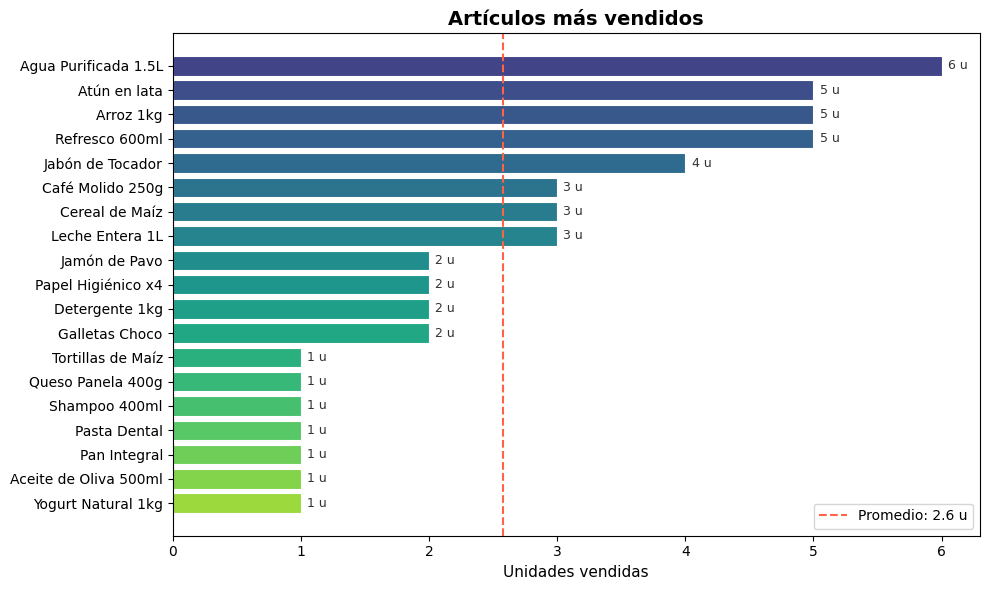

In [13]:
# Ordenar por unidades vendidas
orden       = np.argsort(cantidades)[::-1]
nom_ord     = [nombres_art[i] for i in orden]
cant_ord    = cantidades[orden]
ing_ord     = ingresos[orden]

# Paleta de colores
colores = plt.cm.viridis(np.linspace(0.2, 0.85, len(nom_ord)))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(nom_ord, cant_ord, color=colores, edgecolor='white', linewidth=0.8)

# Anotaciones en cada barra
for bar, val in zip(bars, cant_ord):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{int(val)} u', va='center', fontsize=9, color='#333333')

# Línea de promedio 
prom = np.mean(cant_ord)
ax.axvline(prom, color='tomato', linestyle='--', linewidth=1.5, label=f'Promedio: {prom:.1f} u')

ax.set_xlabel("Unidades vendidas", fontsize=11)
ax.set_title("Artículos más vendidos", fontsize=14, fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

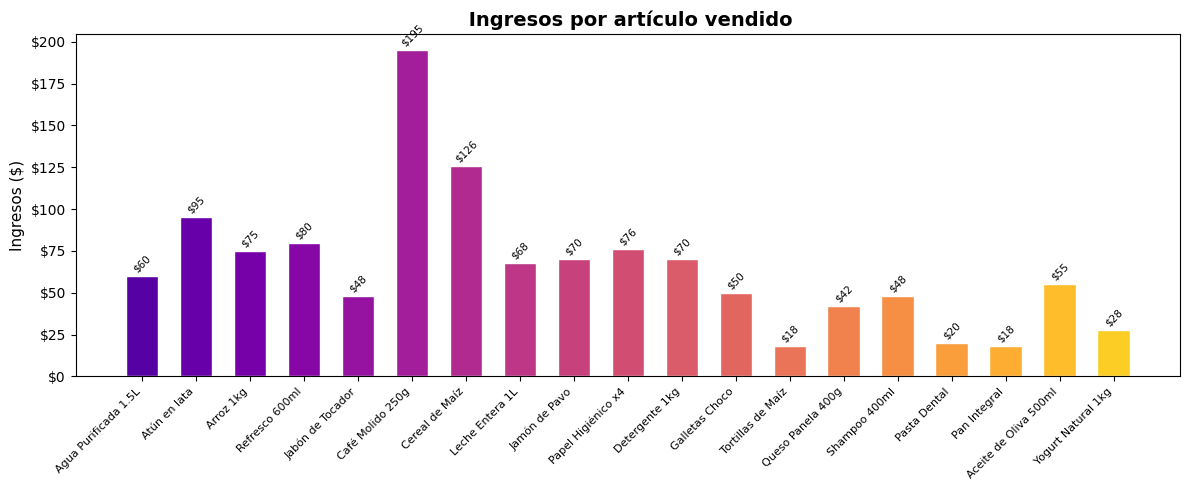

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

x     = np.arange(len(nom_ord))
width = 0.6
colores2 = plt.cm.plasma(np.linspace(0.15, 0.9, len(nom_ord))) #colocar colores dependiendo de las pantillas

bars2 = ax.bar(x, ing_ord, width, color=colores2, edgecolor='white')

# Anotaciones de valor encima de cada barra
for bar, val in zip(bars2, ing_ord):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'${val:.0f}', ha='center', va='bottom', fontsize=7.5, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(nom_ord, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Ingresos ($)", fontsize=11)
ax.set_title(" Ingresos por artículo vendido", fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
plt.tight_layout()
plt.show()

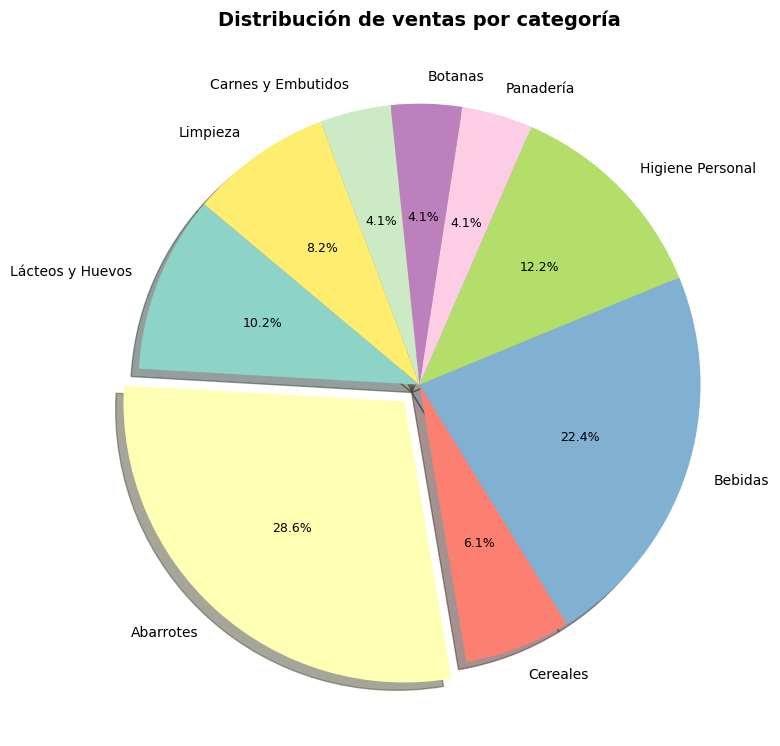

In [15]:
# Agrupar por categoría
ventas_cat = defaultdict(float)
for k, cant in ventas_dict.items():
    cat = inventario.articulos[k].categoria
    ventas_cat[cat] += cant

cats   = list(ventas_cat.keys())
vals   = np.array(list(ventas_cat.values()))
explode = np.where(vals == vals.max(), 0.08, 0)   # Explotar la categoría más vendida

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    vals,
    labels=cats,
    explode=explode,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set3(np.linspace(0, 1, len(cats))),
    shadow=True
)
for at in autotexts:
    at.set_fontsize(9)

ax.set_title("Distribución de ventas por categoría", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

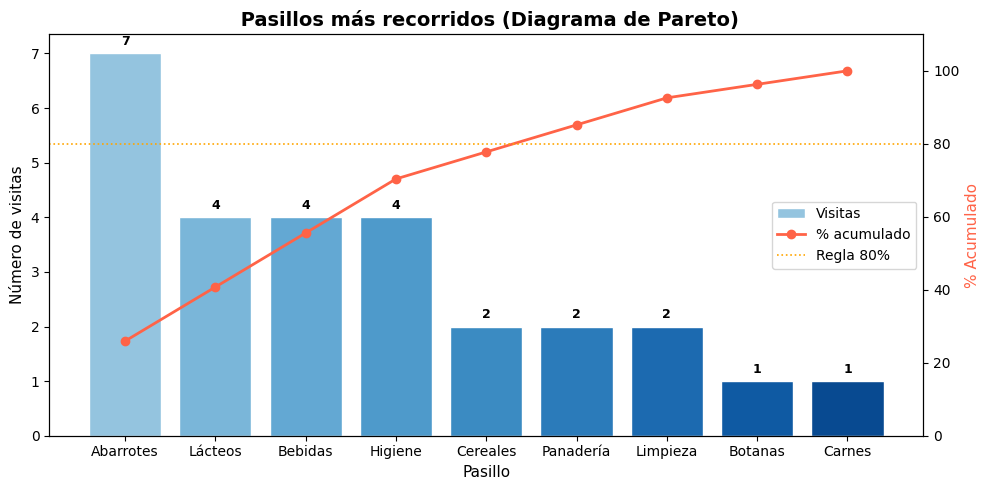

In [16]:
visitas = super_mkt.visitas_por_pasillo
pas_ord = sorted(visitas.items(), key=lambda x: x[1], reverse=True)
pasillos_n = [p[0] for p in pas_ord]
visitas_n  = np.array([p[1] for p in pas_ord], dtype=float)
acumulado  = np.cumsum(visitas_n)
pct_acum   = acumulado / acumulado[-1] * 100   # Porcentaje acumulado

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()   # Eje secundario

colores_pas = plt.cm.Blues(np.linspace(0.4, 0.9, len(pasillos_n)))
bars = ax1.bar(pasillos_n, visitas_n, color=colores_pas, edgecolor='white', label='Visitas')

for bar, v in zip(bars, visitas_n):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(int(v)), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.plot(pasillos_n, pct_acum, color='tomato', marker='o', linewidth=2, label='% acumulado')
ax2.axhline(80, color='orange', linestyle=':', linewidth=1.2, label='Regla 80%')
ax2.set_ylabel("% Acumulado", fontsize=11, color='tomato')
ax2.set_ylim(0, 110)

ax1.set_xlabel("Pasillo", fontsize=11)
ax1.set_ylabel("Número de visitas", fontsize=11)
ax1.set_title(" Pasillos más recorridos (Diagrama de Pareto)", fontsize=14, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.tight_layout()
plt.show()

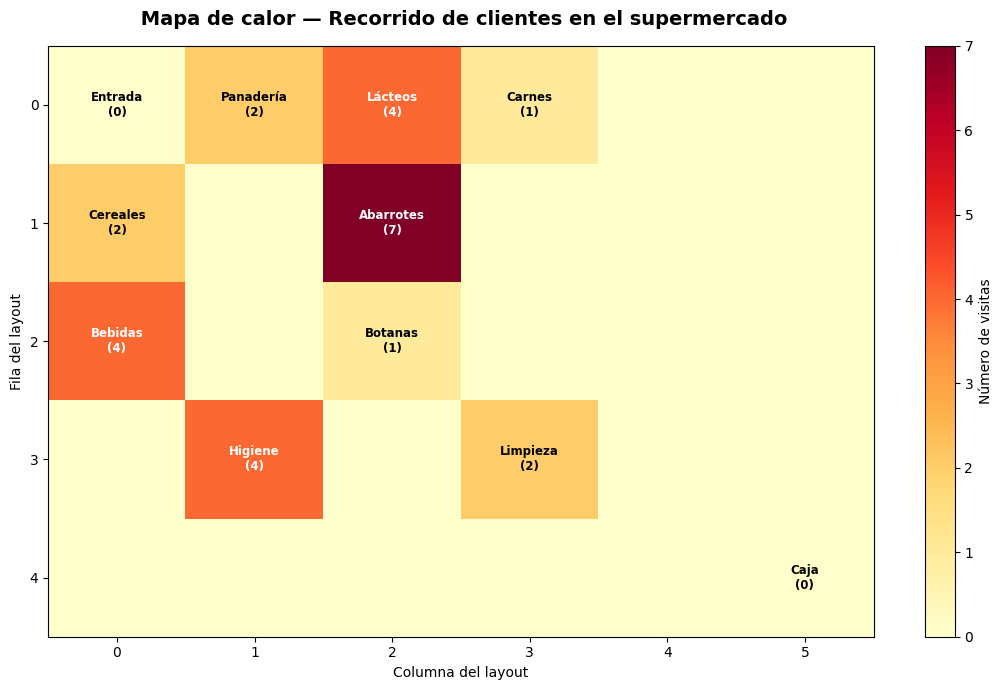

In [17]:
# Layout del supermercado: cada pasillo ocupa una posición (fila, col) en una rejilla 5x6
layout_pasillos = {
    "Entrada":         (0, 0),
    "Panadería":       (0, 1),
    "Lácteos":         (0, 2),
    "Carnes":          (0, 3),
    "Cereales":        (1, 0),
    "Abarrotes":       (1, 2),
    "Bebidas":         (2, 0),
    "Botanas":         (2, 2),
    "Higiene":         (3, 1),
    "Limpieza":        (3, 3),
    "Caja":            (4, 5),
}

# Recopilar todos los recorridos de todos los carritos
todos_carritos = [carrito_ana, carrito_carlos, carrito_maria, carrito_luis]
todos_pasillos = []
for c in todos_carritos:
    todos_pasillos.extend(c.recorrido)

# Generar matriz de calor
mapa_calor = generar_mapa_recorrido(todos_pasillos, layout_pasillos)

# Visualización
fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(mapa_calor, cmap='YlOrRd', aspect='auto', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Número de visitas')

# Anotar cada celda con el nombre del pasillo y el conteo
nombres_en_celda = {(f, c): nombre for nombre, (f, c) in layout_pasillos.items()}
for (f, c), nombre in nombres_en_celda.items():
    conteo = int(mapa_calor[f, c])
    color_texto = 'white' if mapa_calor[f, c] > mapa_calor.max() * 0.5 else 'black'
    ax.text(c, f, f"{nombre}\n({conteo})",
            ha='center', va='center', fontsize=8.5,
            fontweight='bold', color=color_texto)

ax.set_title(" Mapa de calor — Recorrido de clientes en el supermercado",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Columna del layout", fontsize=10)
ax.set_ylabel("Fila del layout", fontsize=10)
ax.set_xticks(range(6))
ax.set_yticks(range(5))
plt.tight_layout()
plt.show()

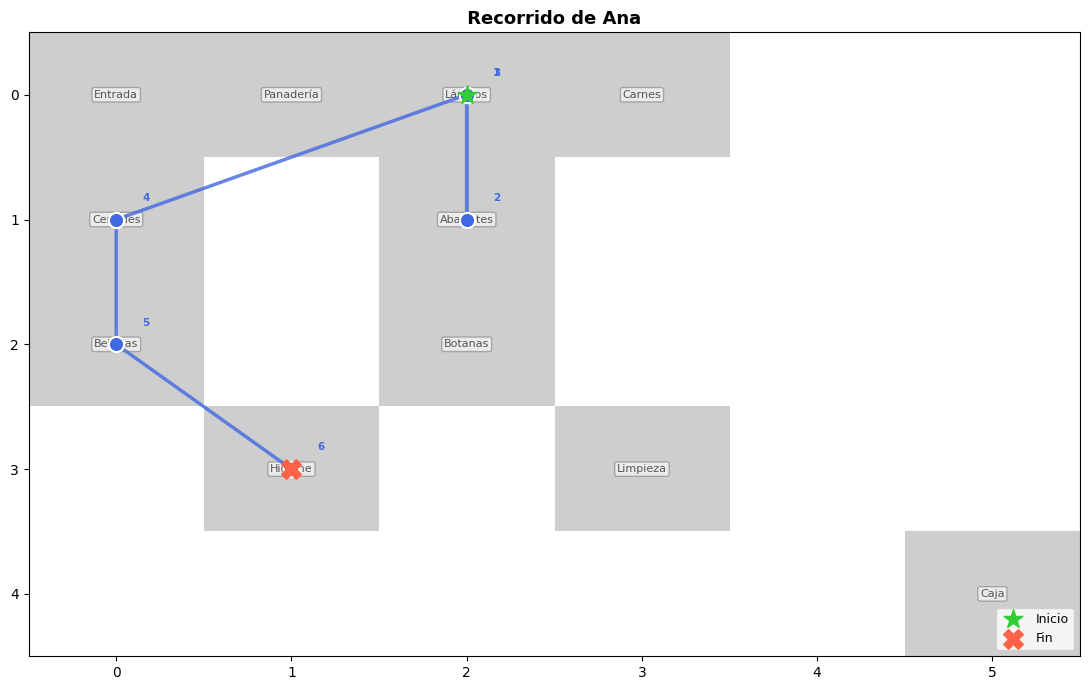

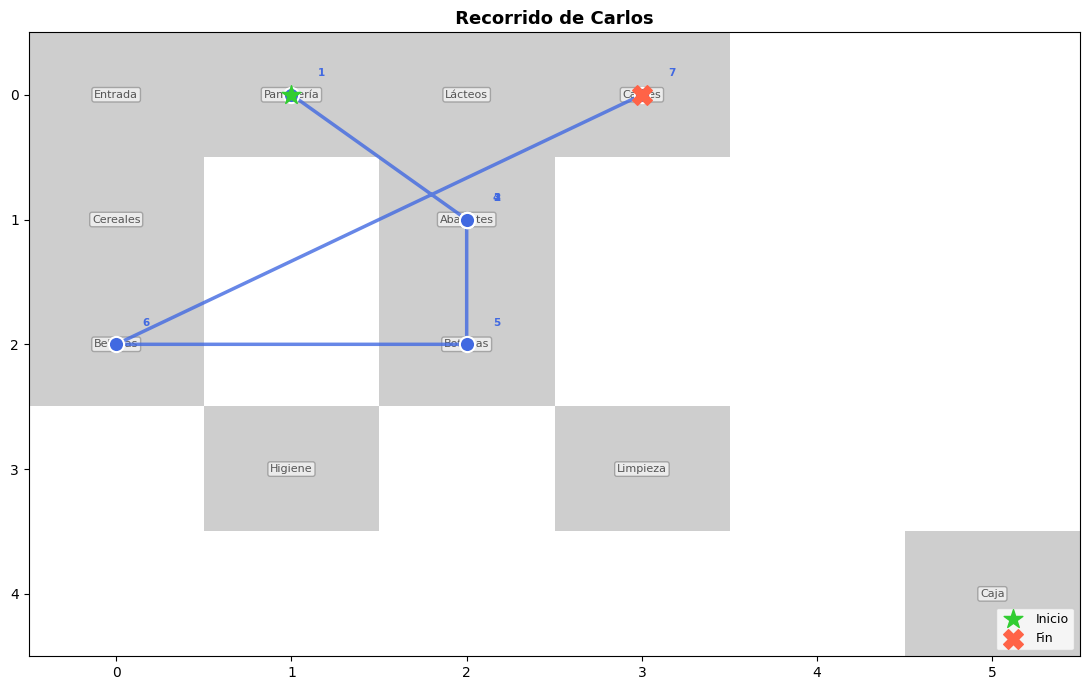

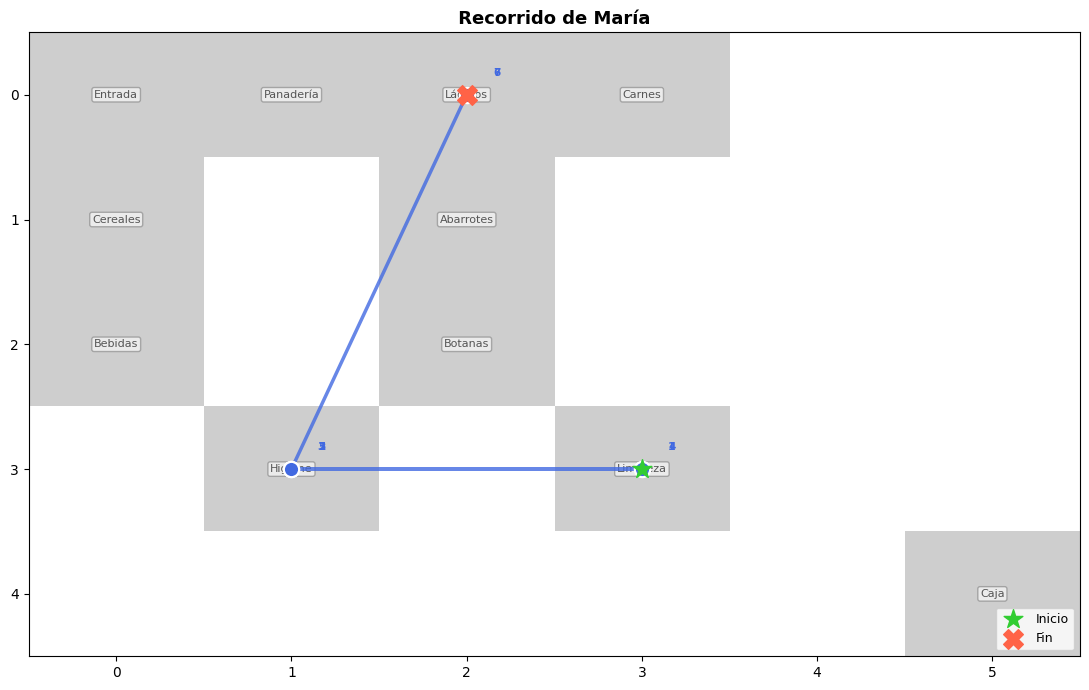

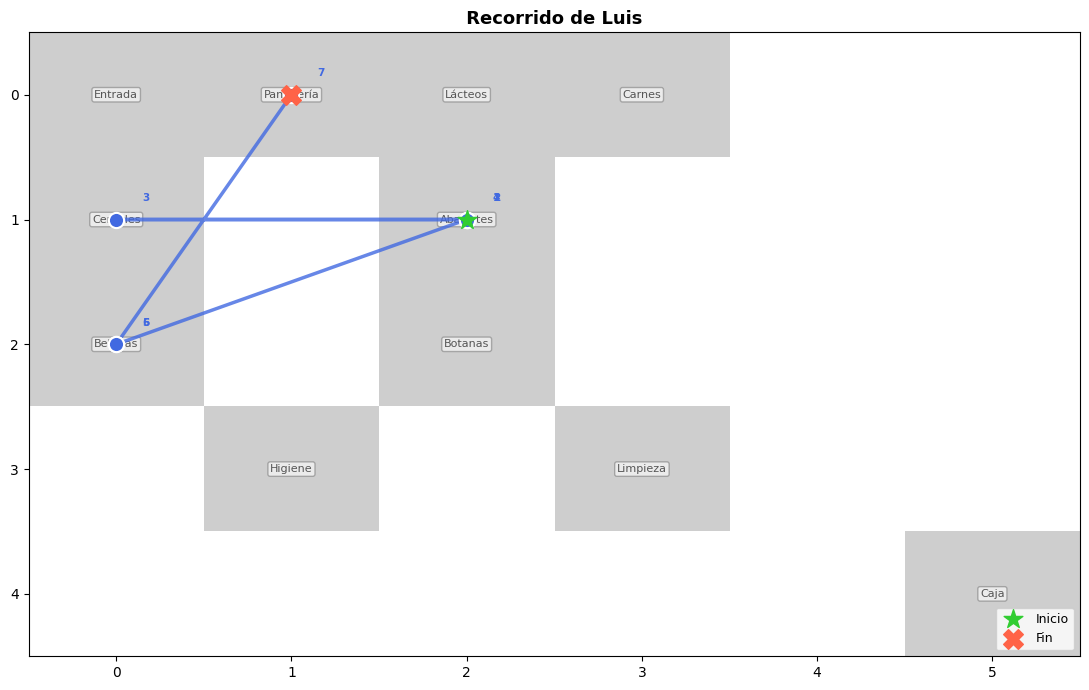

In [18]:
def graficar_recorrido_cliente(carrito, layout_pasillos, titulo_extra=""):
    # Grafica el recorrido de un cliente como trayectoria sobre el mapa del supermercado.
    fig, ax = plt.subplots(figsize=(11, 7))

    # Mapa del supermercado
    mapa_base = np.zeros((5, 6))
    for nombre, (f, c) in layout_pasillos.items():
        mapa_base[f, c] = 0.3
    ax.imshow(mapa_base, cmap='Greys', aspect='auto', vmin=0, vmax=1)

    # Etiquetar todos los pasillos en el mapa
    for nombre, (f, c) in layout_pasillos.items():
        ax.text(c, f, nombre, ha='center', va='center',
                fontsize=8, color='#555555',
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray', boxstyle='round,pad=0.2'))

    # Trazar el recorrido del cliente
    pasillos_rec = carrito.recorrido
    coords       = [layout_pasillos[p] for p in pasillos_rec if p in layout_pasillos]

    if coords:
        fs = [c[0] for c in coords]
        cs = [c[1] for c in coords]

        # Línea del recorrido
        ax.plot(cs, fs, color='royalblue', linewidth=2.5,
                linestyle='-', alpha=0.8, zorder=3)

        # Puntos de parada con número de orden
        for i, (fi, ci) in enumerate(zip(fs, cs)):
            ax.scatter(ci, fi, s=120, color='royalblue', zorder=4, edgecolors='white', linewidths=1.5)
            ax.text(ci + 0.15, fi - 0.15, str(i + 1),
                    fontsize=7.5, color='royalblue', fontweight='bold', zorder=5)

        # Inicio y fin con iconos
        ax.scatter(cs[0], fs[0], s=200, color='limegreen', zorder=5,
                   marker='*', label='Inicio')
        ax.scatter(cs[-1], fs[-1], s=200, color='tomato', zorder=5,
                   marker='X', label='Fin')

    ax.set_title(f" Recorrido de {carrito.cliente_nombre} {titulo_extra}",
                 fontsize=13, fontweight='bold')
    ax.set_xticks(range(6))
    ax.set_yticks(range(5))
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()


# Graficar el recorrido de cada cliente
for carrito in [carrito_ana, carrito_carlos, carrito_maria, carrito_luis]:
    graficar_recorrido_cliente(carrito, layout_pasillos)

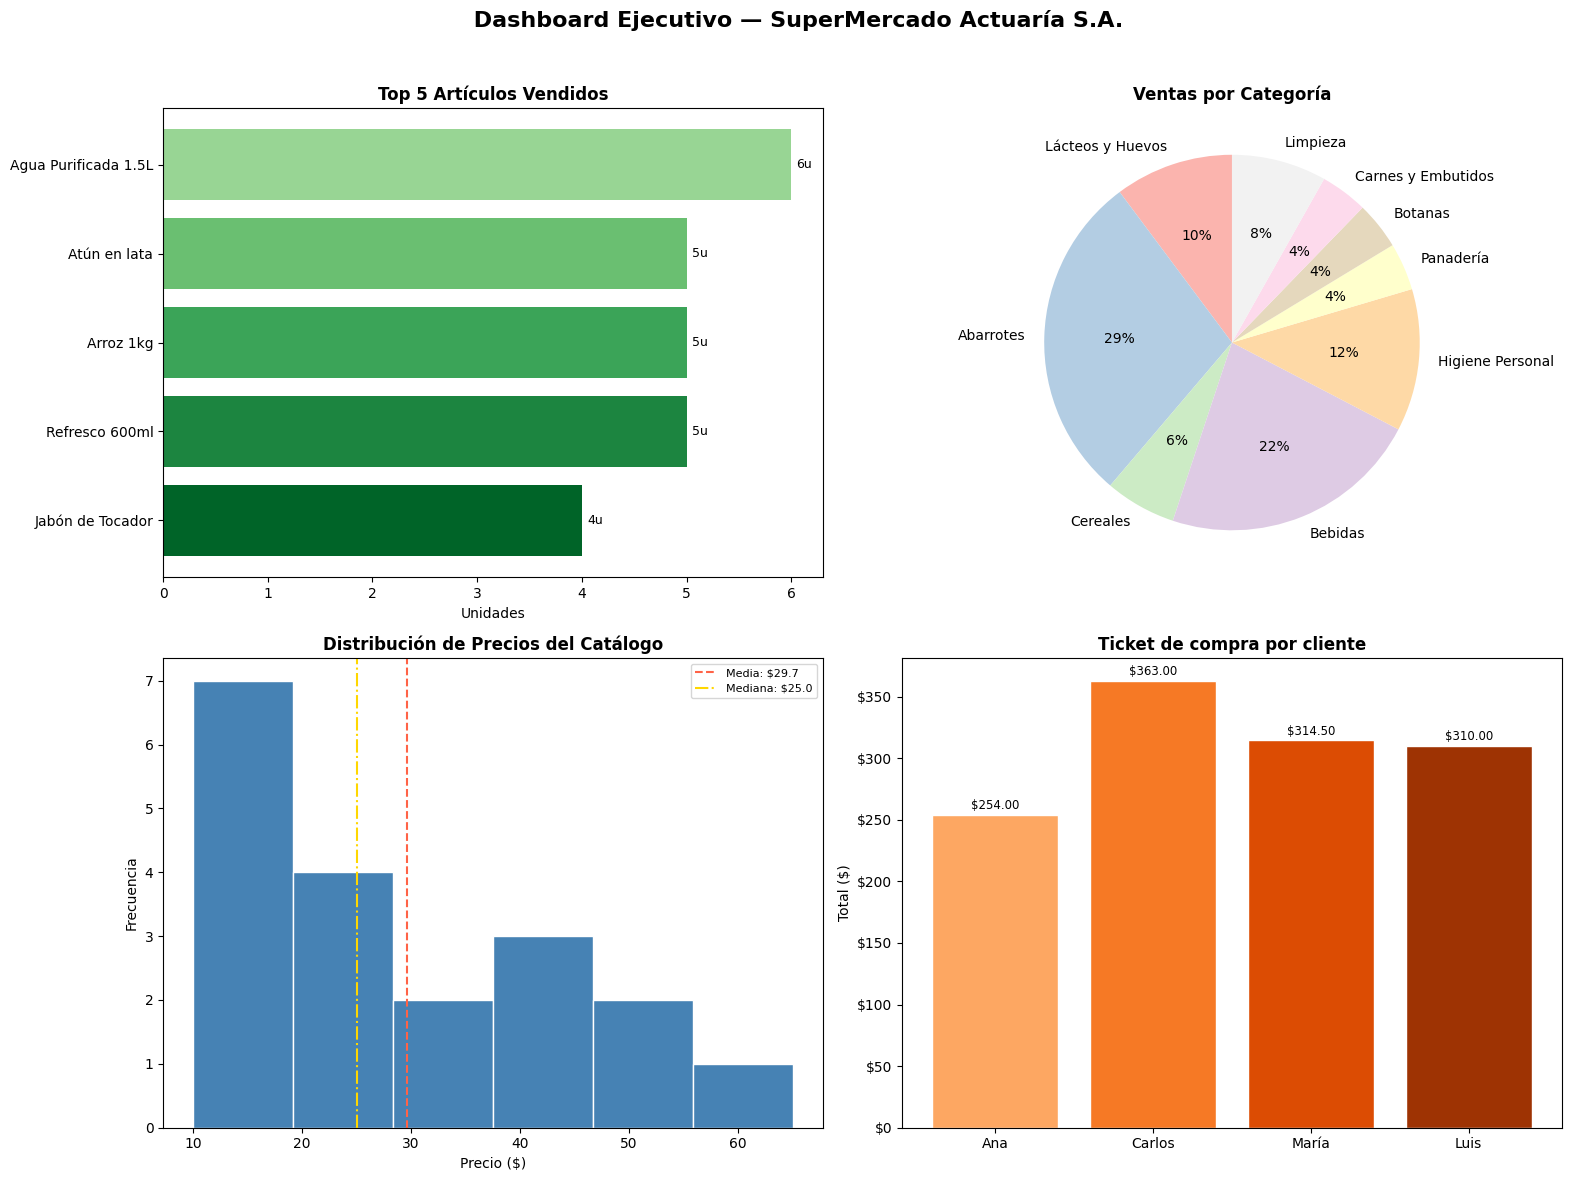

In [19]:
# Dashboard con 4 subplots (Matplotlib subplots avanzados)
fig = plt.figure(figsize=(16, 12))
fig.suptitle(" Dashboard Ejecutivo — SuperMercado Actuaría S.A.",
             fontsize=16, fontweight='bold', y=0.98)

#  Subplot 1: Top 5 artículos más vendidos 
ax1 = fig.add_subplot(2, 2, 1)
top5_idx  = np.argsort(cantidades)[::-1][:5]
top5_nom  = [nombres_art[i] for i in top5_idx]
top5_cant = cantidades[top5_idx]
col1 = plt.cm.Greens(np.linspace(0.4, 0.9, 5))
ax1.barh(top5_nom, top5_cant, color=col1)
ax1.set_title("Top 5 Artículos Vendidos", fontweight='bold')
ax1.set_xlabel("Unidades")
ax1.invert_yaxis()
for i, v in enumerate(top5_cant):
    ax1.text(v + 0.05, i, f'{int(v)}u', va='center', fontsize=9)

#  Subplot 2: Ventas por categoría (pastel) 
ax2 = fig.add_subplot(2, 2, 2)
ax2.pie(vals, labels=cats, autopct='%1.0f%%',
        colors=plt.cm.Pastel1(np.linspace(0, 1, len(cats))),
        startangle=90)
ax2.set_title("Ventas por Categoría", fontweight='bold')

# Subplot 3: Histograma de precios (NumPy + Matplotlib)
ax3 = fig.add_subplot(2, 2, 3)
counts, bin_edges = np.histogram(precios_todos, bins=6)
ax3.bar(bin_edges[:-1], counts, width=np.diff(bin_edges),
        color='steelblue', edgecolor='white', align='edge')
ax3.axvline(np.mean(precios_todos), color='tomato', linestyle='--',
            linewidth=1.5, label=f'Media: ${np.mean(precios_todos):.1f}')
ax3.axvline(np.median(precios_todos), color='gold', linestyle='-.',
            linewidth=1.5, label=f'Mediana: ${np.median(precios_todos):.1f}')
ax3.set_title("Distribución de Precios del Catálogo", fontweight='bold')
ax3.set_xlabel("Precio ($)")
ax3.set_ylabel("Frecuencia")
ax3.legend(fontsize=8)

#  Subplot 4: Ingresos totales por cliente 
ax4 = fig.add_subplot(2, 2, 4)
clientes  = [c.cliente_nombre for c in todos_carritos]
totales   = np.array([c.total() for c in todos_carritos])
col4 = plt.cm.Oranges(np.linspace(0.4, 0.9, len(clientes)))
bars4 = ax4.bar(clientes, totales, color=col4, edgecolor='white')
for bar, val in zip(bars4, totales):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             formatear_moneda(val), ha='center', va='bottom', fontsize=8.5)
ax4.set_title("Ticket de compra por cliente", fontweight='bold')
ax4.set_ylabel("Total ($)")
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

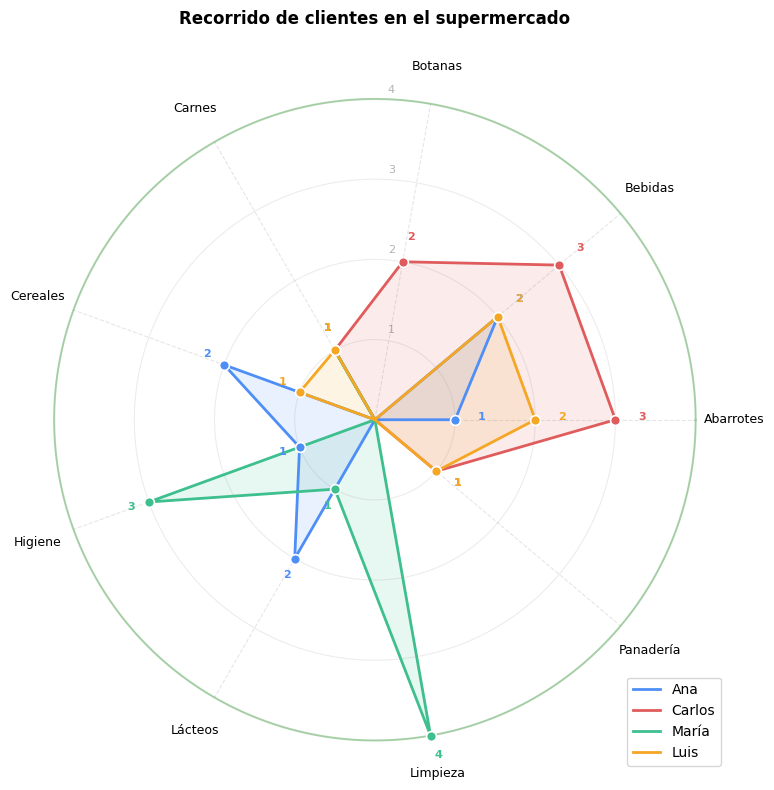

In [20]:
import numpy as np
import matplotlib.pyplot as plt

pasillos = [
    'Abarrotes','Bebidas','Botanas','Carnes',
    'Cereales','Higiene','Lácteos','Limpieza','Panadería'
]
N = len(pasillos)

recorridos = {
    'Ana': [1, 2, 0, 0, 2, 1, 2, 0, 0],
    'Carlos': [3, 3, 2, 1, 0, 0, 0, 0, 1],
    'María': [0, 0, 0, 1, 0, 3, 1, 4, 0],
    'Luis': [2, 2, 0, 1, 1, 0, 0, 0, 1],
}
colores = ['#4E8EF7', '#E05C5C', '#3DBF8E', '#F5A623']
MAX_VISITAS = 4

#  Ángulos: np.linspace(0, 2π, N) distribuye los pasillos en el círculo 
theta = np.linspace(0, 2 * np.pi, N, endpoint=False)

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')
ax.axis('off')

lado = 2 # radio base = lado / 2 = 1

# Anillos de referencia 
for nivel in [1, 2, 3, 4]:
    r_anillo = (nivel / MAX_VISITAS) * (lado / 2)
    t_anillo = np.linspace(0, 2 * np.pi, 300)
    ax.plot((lado/2) * np.cos(t_anillo) * (nivel/MAX_VISITAS),
            (lado/2) * np.sin(t_anillo) * (nivel/MAX_VISITAS),
            color='gray', alpha=0.15, linewidth=0.8)
    ax.text(0.04, r_anillo + 0.02, str(nivel), fontsize=8, color='gray', alpha=0.6)

# Ejes radiales (un eje por pasillo) 
for th in theta:
    ax.plot([0, (lado/2) * np.cos(th)],
            [0, (lado/2) * np.sin(th)],
            color='gray', alpha=0.2, linewidth=0.8, linestyle='--')

# Círculo exterior con la lógica original
t_circ = np.linspace(0, 2 * np.pi, 300)
x_circle = (lado / 2) * np.cos(t_circ)
y_circle = (lado / 2) * np.sin(t_circ)
ax.plot(x_circle, y_circle, 'g-', linewidth=1.5, alpha=0.3)

# Polígono de recorrido por cliente
for (nombre, vals), color in zip(recorridos.items(), colores):
    vals_arr = np.array(vals, dtype=float)
    radios = (vals_arr / MAX_VISITAS) * (lado / 2)

    x_pts = radios * np.cos(theta)
    y_pts = radios * np.sin(theta)

    # Cerrar el polígono
    x_cerrado = np.append(x_pts, x_pts[0])
    y_cerrado = np.append(y_pts, y_pts[0])

    ax.fill(x_cerrado, y_cerrado, color=color, alpha=0.12)
    ax.plot(x_cerrado, y_cerrado, color=color, linewidth=2, label=nombre)

    # Puntos en cada pasillo visitado
    mask = vals_arr > 0
    ax.scatter(x_pts[mask], y_pts[mask],
               color=color, s=50, zorder=5, edgecolors='white', linewidths=1.2)

    # Etiqueta de cantidad
    for i in range(N):
        if vals[i] > 0:
            offset = 0.07
            ax.text(x_pts[i] + offset * np.cos(theta[i]),
                    y_pts[i] + offset * np.sin(theta[i]),
                    str(vals[i]), fontsize=8, color=color, fontweight='bold')

# Etiquetas de pasillos en el borde del círculo
for i, (th, pas) in enumerate(zip(theta, pasillos)):
    pad = 0.12
    ax.text((lado/2 + pad) * np.cos(th),
            (lado/2 + pad) * np.sin(th),
            pas, ha='center', va='center', fontsize=9, fontweight='500')

ax.set_title("Recorrido de clientes en el supermercado\n",
             fontsize=12, fontweight='bold', pad=16)
ax.legend(loc='lower right', framealpha=0.8, fontsize=10)
plt.tight_layout()
plt.show()

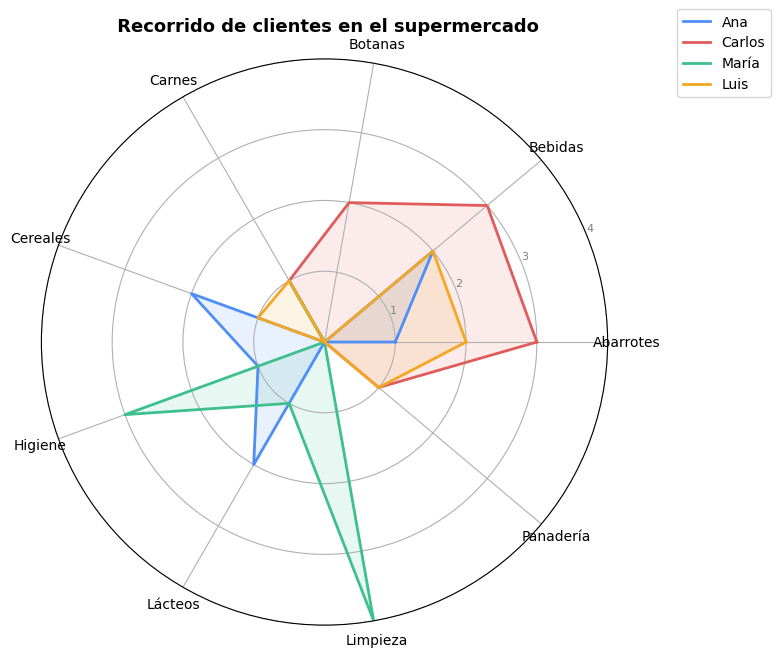

In [21]:
import numpy as np
import matplotlib.pyplot as plt

pasillos = ['Abarrotes','Bebidas','Botanas','Carnes',
            'Cereales','Higiene','Lácteos','Limpieza','Panadería']

clientes_data = {
    'Ana': [1, 2, 0, 0, 2, 1, 2, 0, 0],
    'Carlos': [3, 3, 2, 1, 0, 0, 0, 0, 1],
    'María': [0, 0, 0, 1, 0, 3, 1, 4, 0],
    'Luis': [2, 2, 0, 1, 1, 0, 0, 0, 1],
}
colores = ['#4E8EF7','#E05C5C','#3DBF8E','#F5A623']

N = len(pasillos)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1] # cerrar el polígono

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for (nombre, vals), color in zip(clientes_data.items(), colores):
    valores = vals + vals[:1]
    ax.plot(angles, valores, color=color, linewidth=2, label=nombre)
    ax.fill(angles, valores, color=color, alpha=0.12)

ax.set_thetagrids(np.degrees(angles[:-1]), pasillos, fontsize=10)
ax.set_ylim(0, 4)
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(['1','2','3','4'], fontsize=8, color='gray')
ax.set_title(" Recorrido de clientes en el supermercado",
            fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()
